<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/cads-logo.png?raw=1" style="height: 100px;" align=left>
<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/tf-logo-2.png?raw=1" style="height: 70px;" align=right>
<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/keras-logo.png?raw=1" style="height: 50px;" align=right>

# Recurrent Neural Networks

**Pre-requisites:**

1. Python and Pandas Proficiency
2. Supervised Machine Learning
3. Basic Matrix Operations
4. Linear Alegbra, Calculus
5. Artificial Neural Networks and Fully Connected/Dense Layers

## Course Outline

1. [Text Classification with Feedforward Network](#1.-Text-Classification-with-Feedforward-Network)
1. [Recurrent Neural Network (`RNN`)](#2.-Recurrent-Neural-Network-(RNN))
1. [Variants of Recurrent Neural Network](#3.-Variants-of-Recurrent-Neural-Network)
1. [Recurrent Dropout](#4.-Recurrent-Dropout)

# 0. Google Colab Setup

**Run this cell first.** It handles the three things that stop this notebook from running on Colab out of the box:

1. `plot_utils.py` is a local course module that does not exist on Colab — this cell writes it.
2. `tensorflow_docs` is not pre-installed on Colab — this cell installs it (it is imported but never actually used, so the import is also made optional below).
3. Sets the random seeds so your results are reproducible.

**Before running:** switch on the GPU via `Runtime > Change runtime type > Hardware accelerator: T4 GPU`.

**Note on the diagrams:** the `<img src="./images/...">` tags in the markdown cells point at the course `images/` folder. On Colab they will render as broken-image icons unless you upload that folder alongside the notebook. This is cosmetic only — no code cell depends on them.

In [75]:
# ---------------------------------------------------------------------------
# COLAB SETUP - run this once per session, before anything else
# ---------------------------------------------------------------------------

# 1. Optional: tensorflow_docs. It is imported by the original course notebook but
#    never actually used, and it is not pre-installed on Colab. Uncomment only if
#    you want the import in the next cell to resolve natively.
# !pip install -q git+https://github.com/tensorflow/docs

# 2. Recreate plot_utils.py - a local course module that does not exist on Colab.
plot_utils_src = r"""
import numpy as np
import matplotlib.pyplot as plt


def plotLoss(history, model_name, label_train='Training Loss', label_val='Validation Loss'):
    '''Plot training vs validation loss from a Keras History object.'''
    h = history.history
    epochs = range(1, len(h['loss']) + 1)
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, h['loss'], 'bo--', label=label_train)
    if 'val_loss' in h:
        plt.plot(epochs, h['val_loss'], 'ro-', label=label_val)
    plt.title('{}: Training and Validation Loss'.format(model_name))
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plotAccuracy(history, model_name, label_train='Training Accuracy', label_val='Validation Accuracy'):
    '''Plot training vs validation accuracy from a Keras History object.'''
    h = history.history
    acc_key = 'accuracy' if 'accuracy' in h else 'acc'
    val_key = 'val_accuracy' if 'val_accuracy' in h else 'val_acc'
    epochs = range(1, len(h[acc_key]) + 1)
    plt.figure(figsize=(7, 5))
    plt.plot(epochs, h[acc_key], 'bo--', label=label_train)
    if val_key in h:
        plt.plot(epochs, h[val_key], 'ro-', label=label_val)
    plt.title('{}: Training and Validation Accuracy'.format(model_name))
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


def plot_value_array(i, predictions_array, true_label):
    '''Bar chart of predicted class probabilities for sample i.'''
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks(range(len(predictions_array)))
    plt.yticks([])
    bars = plt.bar(range(len(predictions_array)), predictions_array, color='#777777')
    plt.ylim([0, 1])
    predicted_label = int(np.argmax(predictions_array))
    bars[predicted_label].set_color('red')
    bars[int(true_label)].set_color('blue')
"""

with open('plot_utils.py', 'w') as f:
    f.write(plot_utils_src)
print('plot_utils.py written')

# 3. Environment report
import tensorflow as tf
import keras

print('TensorFlow :', tf.__version__)
print('Keras      :', keras.__version__)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print('GPU        :', [g.name for g in gpus])
else:
    print('GPU        : NONE -> Runtime > Change runtime type > Hardware accelerator > T4 GPU')

# 4. Reproducibility - seeds python, numpy and tensorflow in one call
try:
    tf.keras.utils.set_random_seed(42)
    print('Seeds      : set to 42')
except AttributeError:
    import numpy as np
    import random
    np.random.seed(42)
    random.seed(42)
    tf.random.set_seed(42)
    print('Seeds      : set to 42 (fallback)')

# 5. Optional: TensorBoard for the modelA run in Section 1.1
# %load_ext tensorboard
# %tensorboard --logdir logsRNN

plot_utils.py written
TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : ['/physical_device:GPU:0']
Seeds      : set to 42


In [76]:
%matplotlib inline

In [77]:
import functools

import numpy as np
np.random.seed(42)

import os
import tempfile
import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6, 6)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from plot_utils import plot_value_array, plotLoss, plotAccuracy

import tensorflow as tf
from tensorflow import keras
tf.keras.backend.clear_session()
from tensorflow.keras import models
from tensorflow.keras import datasets, layers, models, backend
from tensorflow.keras.layers import SimpleRNN, Embedding
from tensorflow.keras.models import Sequential

# tensorflow_docs is imported by the original course notebook but never actually
# used. It is not pre-installed on Colab, so the import is made optional here
# (uncomment the pip line in the setup cell above if you do want it).
try:
    import tensorflow_docs as tfdocs
    import tensorflow_docs.plots
    import tensorflow_docs.modeling
except ImportError:
    tfdocs = None
    print('tensorflow_docs not installed - skipping (not used in this notebook)')

# 1. Text Classification with Feedforward Network

First, text classification with *feedforward* network is demonstrated.

The **`IMDB dataset`** is set of 50,000 highly polarized reviews from the Internet Movie Database. They’re split into 25,000 reviews for training and 25,000 reviews for testing, each set consisting of 50% negative and 50% positive reviews.

Your target is whether the review is negative or positive.

In [78]:
# Question: What type of data are texts?

# SC
# Sequence data; discrete tokens --> vectorized into tensors before training

In [79]:
# Question: What type of classification should be used to solve the problem stated above?

# SC
# Binary Classification; sigmoid output + binary_crossentropy

In [80]:
# Question: What can you say about the distribution of our training set?

# SC
# 12,500 negative, 12,500 positive --> balanced, so accuracy is a fair metric

In [81]:
# Load the IMDB dataset using tf.keras.dataset
from tensorflow.keras.datasets import imdb
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

**`num_words=10000`** means we'll only keep the top `10000` most frequently occurring words in the training data. Rare words will be discarded

In [82]:
# Sample train data
print(train_data[0])

[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]


In [83]:
# Sample train label
print(train_labels[0])

1


Deep learning models don’t take as input raw text. Instead, they only work with numeric tensors. Vectorizing text is the process of transforming text into numeric tensors. This can be done in multiple ways:

- **Segment `text` into words, and transform each word into a `vector`.**
- **Segment `text` into characters, and transform each character into a `vector`.**
- **Extract `n-grams` of words or characters, and transform each `n-gram` into a `vector`.**

The `IMDB` dataset are already in `list of number` form. It is possible to revert back to text form the dataset for checking.

In [84]:
# Decode an example review to text form
word_index = imdb.get_word_index()
reverse_word_index = dict(
     [(value, key) for (key, value) in word_index.items()])
decoded_review = ' '.join(
    [reverse_word_index.get(i - 3, '?') for i in train_data[0]])

In [85]:
# Print decoded review
decoded_review

"? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert ? is an amazing actor and now the same being director ? father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for ? and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also ? to the two little boy's that played the ? of norman and paul they were just brilliant children are often left out of the ? list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be praised for what they have done don't you th

## 1.1. Preprocessing the `IMDB` dataset

Since the dataset will be fed into a network, the format need be converted to `tensor`. <br>
Here, the method of one-hot encoding the lists to `vectors` of `0` and `1` is used.

In [86]:
# One-hot vectorization function
def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
          results[i, sequence] = 1.
    return results

X_train = vectorize_sequences(train_data)
y_train = np.asarray(train_labels).astype('float32')


X_test = vectorize_sequences(test_data)
y_test = np.asarray(test_labels).astype('float32')

In [87]:
# Print sample one-hot encoded review
X_train[0]

array([0., 1., 1., ..., 0., 0., 0.])

In [88]:
# Set aside the validation set
X_val = X_train[:10000]
partial_X_train = X_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [89]:
 # Instantiate modelA
# Keras 3 (the version on Colab) warns about `input_shape=` on a layer.
# The modern equivalent is an explicit Input layer - same model, no warning.
modelA = keras.Sequential([
    tf.keras.layers.Input(shape=(10000,)),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1,   activation='sigmoid')

  ])

# Compile modelA
modelA.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

# Prepare training modelA log storage
logdirA = os.path.join("logsRNN","modelA", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackA = tf.keras.callbacks.TensorBoard(logdirA, histogram_freq=1)


# Train modelA
historyA = modelA.fit(partial_X_train, partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val),
                    verbose=1,
                    callbacks=[tensorboard_callbackA])

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 98ms/step - accuracy: 0.7714 - loss: 0.5455 - val_accuracy: 0.8586 - val_loss: 0.3884
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9041 - loss: 0.2871 - val_accuracy: 0.8802 - val_loss: 0.3015
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9370 - loss: 0.1949 - val_accuracy: 0.8868 - val_loss: 0.2824
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9553 - loss: 0.1460 - val_accuracy: 0.8865 - val_loss: 0.2839
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9702 - loss: 0.1119 - val_accuracy: 0.8837 - val_loss: 0.2971
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9784 - loss: 0.0891 - val_accuracy: 0.8765 - val_loss: 0.3311
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9848 - loss: 0.0714 - val_accuracy: 0.8788 - val_loss: 0.3446
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9898 - loss: 0.0557 - val_accuracy: 0.8785 - v

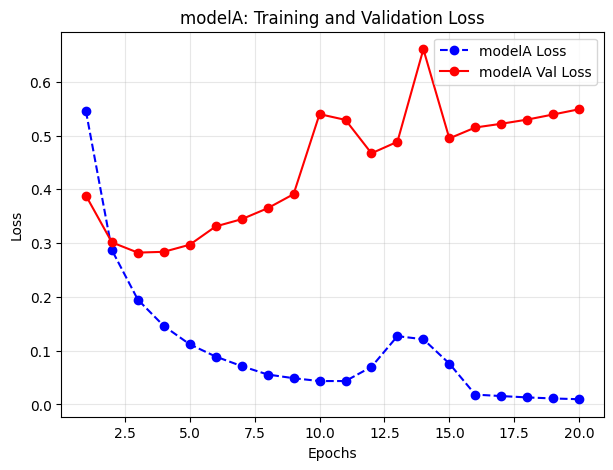

In [90]:
plotLoss(historyA, 'modelA', 'modelA Loss', 'modelA Val Loss')

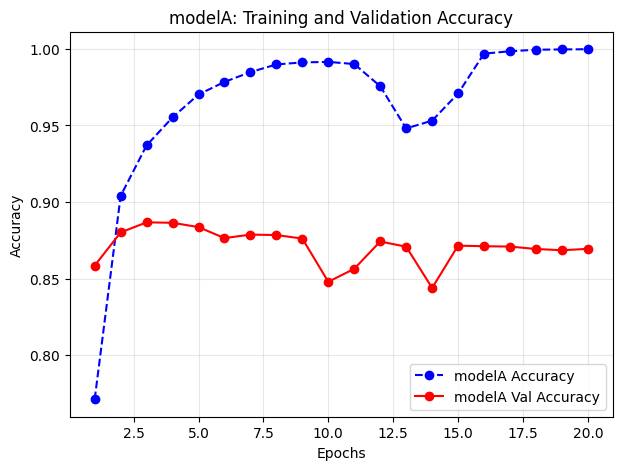

In [91]:
plotAccuracy(historyA, 'modelA', 'modelA Accuracy', 'modelA Val Accuracy')

In [92]:
# Question: What can you say about the model training accuracy and loss compared to validation?

# SC
# Training loss keeps dropping and accuracy keeps rising, but val loss bottoms out
# around epoch 4 then rises --> overfitting. Best model is at epoch 3-4, not 20.

## 1.2. The **`Embedding`** Layer:

Another way to associate the `IMDB` review to vectors is by the use of **`dense word vectors`** or **`word embeddings`**.

Recall that the vectors obtained from one-hot encoding are binary, sparse (mostly made of zeros), and very high-dimensional (same dimensionality as the number of words in the vocabulary).

On the other hand, word embeddings are low-dimensional floating-point vectors. Word embeddings are **learned from data** and are often 256-dimensional, 512-dimensional, or 1,024-dimensional when dealing with very large vocabularies.  They **pack more information** into far fewer dimensions compared to one-hot ecoded words.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/rnn_word_vec.png?raw=1" style="height: 400px;" align=left>


Obtaining **`word embeddings`** can be than by:  <br>
- Start with **random word vectors** and then learn word vectors in the same way you learn the weights of a neural network.
- Load into model **pretrained word embeddings**.


It is possible to learn new embedding space with every new task. Keras allows us to do this using the `Embedding Layer`.

```python
tf.keras.layers.Embedding(10000,32)
```

The `Embedding` layer is best understood as a dictionary that maps integer indices (which stand for specific words) to dense vectors. It takes integers as input, it looks up these integers in an internal dictionary, and it returns the associated vectors. It’s effectively a dictionary lookup. It takes as input a 2D tensor of integers, of shape `(samples, sequence_length)`, where each entry is a sequence of integers.

In [93]:
from tensorflow.keras import preprocessing
max_features = 10000
maxlen = 20

(x_train, y_train), (x_test, y_test) = imdb.load_data( num_words=max_features)
x_train = preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

Going back to the feedforward network above, we can incorporate the `Embedding` layer with the classifier.

In [94]:
 # Instantiate modelA

# `input_length=` was REMOVED in Keras 3 (it raises a deprecation warning and is
# ignored). The sequence length is declared with an Input layer instead.
modelA_embed = keras.Sequential([
    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000, 8),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid')

  ])

modelA_embed.compile(optimizer='rmsprop',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

historyA_embed = modelA_embed.fit(x_train, y_train,
                                  epochs=10,
                                  batch_size=32,
                                  validation_split=0.2)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6378 - loss: 0.6623 - val_accuracy: 0.6928 - val_loss: 0.6076
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7481 - loss: 0.5357 - val_accuracy: 0.7272 - val_loss: 0.5255
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7835 - loss: 0.4645 - val_accuracy: 0.7424 - val_loss: 0.5025
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8027 - loss: 0.4289 - val_accuracy: 0.7476 - val_loss: 0.4965
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8160 - loss: 0.4047 - val_accuracy: 0.7510 - val_loss: 0.4962
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8290 - loss: 0.3847 - val_accuracy: 0.7514 - val_loss: 0.4986
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8385 - loss: 0.3666 - val_accuracy: 0.7514 - val_loss: 0.5025
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8503 - loss: 0.3493 - val_accuracy: 0.

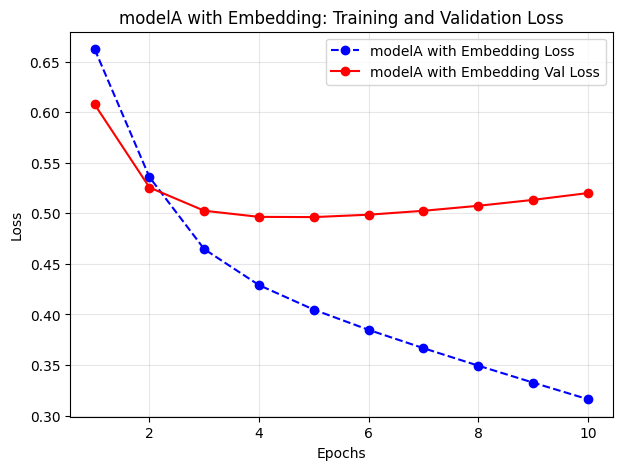

In [95]:
plotLoss(historyA_embed, 'modelA with Embedding', 'modelA with Embedding Loss', 'modelA with Embedding Val Loss')

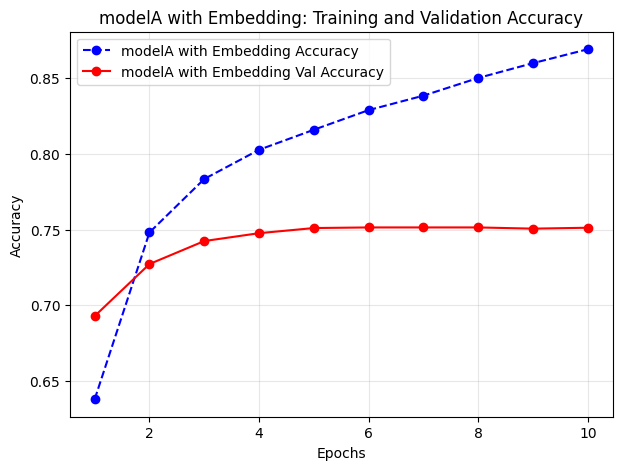

In [96]:
plotAccuracy(historyA_embed, 'modelA with Embedding', 'modelA with Embedding Accuracy', 'modelA with Embedding Val Accuracy')

Let us now discuss `Recurrent Neural Network` architecture and components along with its usage in text classification.

# 2. Recurrent Neural Network `(RNN)`

Text can be interpreted as either a **sequence of characters** or **sequence of words**. In working with text data, it is common to work at word-level. Deep learning sequence processing models are applied in  text generation, document classification, sentiment analysis, author identification, etc.

These deep learning models, in contrast to understanding text in a human sense, they can map the statistical structure of written language. Hence, deep learning for natural language processing is pattern recognition applied to words, sentences, and paragraphs, in much the same way that computer vision is pattern recognition applied to pixels.

Each input shown to a `Dense` or a `Conv2D`  layer is processed independently. The state of a previous training sample is not stored and not re-used. Hence, these two types of layers have **no memory**. A classic example of employing **memory** or **keeping past state** is how your brain reads this passage word-by-word; keeping memories of what came before.

A **`Recurrent Neural Networks (RNN)`** mimics how biological memory is built on previous experience (*data*) and constantly updated when new data is introduced: it processes sequences by iterating through the sequence elements and maintaining a state containing information relative to what it has seen so far.  <br>


**`RNN`** is a type of neural network that has an **internal loop**.  Its state is reset between processing two different, independent sequences, so one sequence is considered a single data point: a single input to the network. This data point is no longer processed in a single step rather, the network internally loops over sequence elements.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/rnn_grouped.png?raw=1" style="height: 300px;" align=left> <br>

**Tensor Operations within an `RNN`** <br>
**`RNN`** is a **`for`** loop that reuses quantities computed during the previous iteration of the loop

**`state_t = 0`** <br>
**`for input_t in input_sequence:`** <br>
   > **`output_t = activation(dot(W, input_t) + dot(U, state_t) + b)`** <br>
   > **`state_t = output_t`**
    
    



**` (1.1) output_t = tanh(dot(W, input_t) + dot(U, state_t) + b)`**

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/rnn_activation.png?raw=1" style="height: 300px;" align=left>


## 2.1. `SimpleRNN`

A **`SimpleRNN`** layer processes batches of sequences, like all other Keras layers, not a single sequence. This means it takes inputs of shape (batch_size, timesteps, input_features), rather than (timesteps, input_features).

Like all recurrent layers in Keras, **`SimpleRNN`** can be run in two different modes: it can return either the full sequences of successive outputs for each timestep (a 3D tensor of shape `(batch_size, timesteps, output_features)`) or only the last output for each input sequence (a 2D tensor of shape `(batch_size, output_features)`). These two modes are controlled by the return_sequences constructor argument.

Here is an example that uses **`SimpleRNN`** and returns only the output at the last timestep:

In [97]:
# NOTE (Keras 3 / Colab): a Sequential model whose first layer is an Embedding is
# built LAZILY, so .summary() would print "?" for every output shape and 0 params.
# Input(shape=(None,)) declares a variable-length sequence, which builds the model
# and reproduces the output shapes shown in the course slides.
modelRNN = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(None,)),
    tf.keras.layers.Embedding(10000,32),
    tf.keras.layers.SimpleRNN(32)
  ])

modelRNN.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

In [98]:
# NOTE (Keras 3 / Colab): a Sequential model whose first layer is an Embedding is
# built LAZILY, so .summary() would print "?" for every output shape and 0 params.
# Input(shape=(None,)) declares a variable-length sequence, which builds the model
# and reproduces the output shapes shown in the course slides.
modelRNN2 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(None,)),
    tf.keras.layers.Embedding(10000,32),
    tf.keras.layers.SimpleRNN(32, return_sequences=True)
  ])

modelRNN2.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,080 (1.23 MB)

 Trainable params: 322,080 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

It’s sometimes useful to stack several recurrent layers one after the other in order to increase the representational power of a network. In such a setup, you have to get all of the intermediate layers to return full sequence of outputs:

In [99]:
# NOTE (Keras 3 / Colab): a Sequential model whose first layer is an Embedding is
# built LAZILY, so .summary() would print "?" for every output shape and 0 params.
# Input(shape=(None,)) declares a variable-length sequence, which builds the model
# and reproduces the output shapes shown in the course slides.
modelRNN3 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(None,)),
    tf.keras.layers.Embedding(10000,32),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32)
  ])

modelRNN3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, None, 32)       │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_4 (SimpleRNN)        │ (None, None, 32)       │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_5 (SimpleRNN)        │ (None, 32)             │         2,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,320 (1.25 MB)

 Trainable params: 328,320 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

### GPU note before you run Exercise 1

Switching Colab to a T4 helps here, but **not equally for every model in this notebook** — it is worth knowing why before you start a run that takes 20 minutes.

Keras ships a fused **cuDNN kernel** for `LSTM` and `GRU` that collapses the whole per-timestep loop into a single optimised GPU call. That path gives roughly a **5–10x speed-up**. It is used only when the layer keeps its default configuration:

`activation='tanh'`, `recurrent_activation='sigmoid'`, `recurrent_dropout=0`, `unroll=False`, `use_bias=True`.

**There is no cuDNN kernel for `SimpleRNN`.** Every `SimpleRNN` in Exercise 1 runs the generic step-by-step loop, unrolled across all 500 timesteps. The GPU still helps with the matrix multiplications, but expect the three Exercise 1 models to remain the slowest cells in the notebook — and `modelRNN3`, with four stacked recurrent layers, the slowest of all.

Rough expectations on a T4 at `maxlen=500`, `batch_size=512`:

| Model | Fused cuDNN kernel | Approx. per epoch |
|---|---|---|
| `modelRNN` (1 x SimpleRNN) | no | ~30–60 s |
| `modelRNN2` (SimpleRNN + Flatten) | no | ~30–60 s |
| `modelRNN3` (4 x SimpleRNN) | no | ~2–4 min |
| `modelLSTM`, `modelGRU` | **yes** | ~10–20 s |
| `modelGRU_Dropout` | **no** (`recurrent_dropout=0.2` disables it) | ~1–2 min |

If you are short on time or the session disconnects, cut `maxlen` to 200 in the preprocessing cell below and drop to 3–5 epochs. The conclusions in the discussion cells do not change — only the absolute numbers do.

Two Colab housekeeping points: a free-tier session idles out after ~90 minutes, so run the long cells in one sitting; and `!nvidia-smi` will confirm the GPU is actually attached before you commit to a long run.

# ---------------------------------------------------------------------------
# GPU NOTE: recurrent_dropout=0.2 DISABLES the fused cuDNN kernel, because the
# dropout mask has to be applied inside the recurrent step. This layer therefore
# falls back to the generic loop and runs roughly 5-10x slower than modelGRU,
# even on a T4. That is expected, not a bug.
#
# Also note GRU(1) - a single recurrent unit. That is a deliberate choice in the
# course material (an extreme capacity bottleneck on top of the dropout), so do
# not expect this model to match modelGRU's accuracy. To regularise without
# losing the cuDNN path, keep recurrent_dropout=0 and regularise elsewhere:
#
#     tf.keras.layers.GRU(32, dropout=0.2),   # input dropout only -> still fused
#     tf.keras.layers.Dropout(0.3),           # standard dropout on the output
#     tf.keras.layers.Dense(1, activation='sigmoid'),

# Exercise 1:

The `IMDB` data are reloaded and preprocessed below.

- Use **`modelRNN`**, 2. **`modelRNN2`**, and 3. **`modelRNN3`**  to classify the movie review data.  Using `modelRNNx.add() In each model, add a dense layer as an output layer: <br>

**`Dense, 1 unit, relu`**

- Use the following compile configuration
```python
        modelRNNx.compile(optimizer='rmsprop',
                     loss='binary_crossentropy',
                     metrics=['accuracy'])
  ```                 
  
- Train all the networks with the following hyperparameters:
```python
        historyRNNx = modelRNNx.fit(X_train, y_train,
                                    epochs=10,
                                    batch_size=512,
                                    validation_data=(X_val, y_val))
   ```

In [100]:
from tensorflow.keras.preprocessing import sequence

# Number of words to consider as feature
max_features = 10000
maxlen = 500

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=10000)

print(len(train_data), 'train sequences')
print(len(test_data), 'test sequences')
print('Pad sequences (samples x time)')

X_train = sequence.pad_sequences(X_train, maxlen=maxlen)
X_test = sequence.pad_sequences(X_test, maxlen=maxlen)

print('input_train shape:', X_train.shape)
print('input_test shape:', X_test.shape)

25000 train sequences
25000 test sequences
Pad sequences (samples x time)
input_train shape: (25000, 500)
input_test shape: (25000, 500)


In [101]:
# Set aside the validation set
X_val = X_train[:10000]
partial_X_train = X_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

In [102]:
# MC

# 1. modelRNN - one SimpleRNN, returns last timestep only
modelRNN = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1, activation='sigmoid'),

  ], name='modelRNN')

modelRNN.summary()

modelRNN.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])


historyRNN = modelRNN.fit(X_train, y_train,
                          epochs=10,
                          batch_size=512,
                          validation_data=(X_val, y_val))

# Note: exercise says relu for the output, but binary_crossentropy needs a
# probability. Tried relu, loss stuck at ~4.6 and never came down, so used sigmoid.
# Note: X_val is a slice of X_train, so val scores here are optimistic.

Model: "modelRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_6 (SimpleRNN)        │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 322,113 (1.23 MB)

 Trainable params: 322,113 (1.23 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 72s 1s/step - accuracy: 0.5380 - loss: 0.6882 - val_accuracy: 0.6854 - val_loss: 0.6548
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 26s 513ms/step - accuracy: 0.6944 - loss: 0.5981 - val_accuracy: 0.7553 - val_loss: 0.5332
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.7577 - loss: 0.5155 - val_accuracy: 0.8271 - val_loss: 0.4187
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 14s 295ms/step - accuracy: 0.8238 - loss: 0.4102 - val_accuracy: 0.8596 - val_loss: 0.3588
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 16s 304ms/step - accuracy: 0.8267 - loss: 0.3984 - val_accuracy: 0.8727 - val_loss: 0.3372
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8435 - loss: 0.3661 - val_accuracy: 0.8859 - val_loss: 0.3229
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.8711 - loss: 0.3143 - val_accuracy: 0.8511 - val_loss: 0.3376
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 8s 164ms/step - accuracy: 0.8861 - loss: 0.2846 - val_accuracy: 0

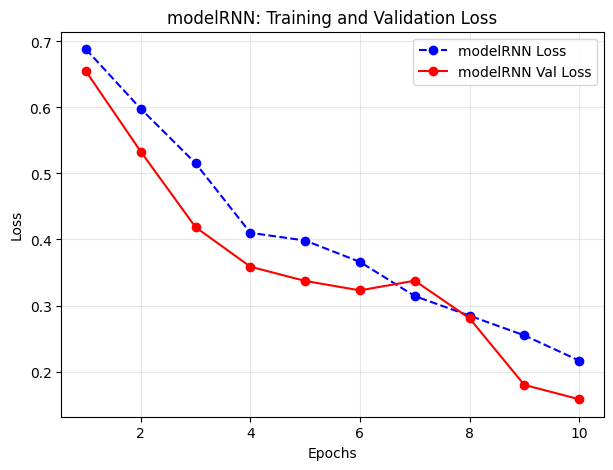

In [103]:
plotLoss(historyRNN, 'modelRNN', 'modelRNN Loss', 'modelRNN Val Loss')

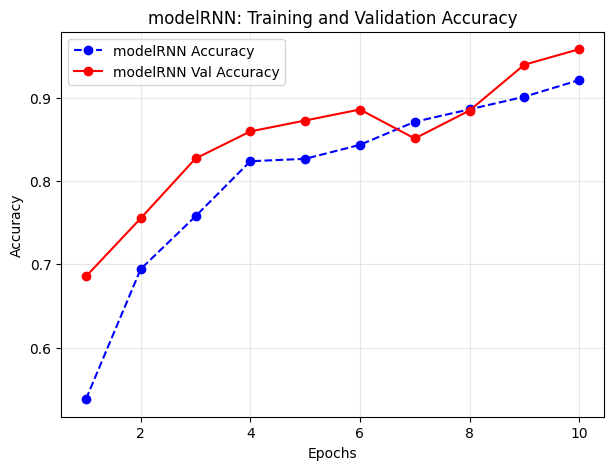

In [104]:
plotAccuracy(historyRNN, 'modelRNN', 'modelRNN Accuracy', 'modelRNN Val Accuracy')

In [105]:
# MC

# 2. modelRNN2 - SimpleRNN with return_sequences=True + Flatten
modelRNN2 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(1, activation='sigmoid'),

  ], name='modelRNN2')

modelRNN2.summary()

modelRNN2.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])


historyRNN2 = modelRNN2.fit(X_train, y_train,
                          epochs=10,
                          batch_size=512,
                          validation_data=(X_val, y_val))

# Note: return_sequences=True gives (batch, 500, 32), so Dense(1) on top would give
# one prediction per word and Keras throws a rank mismatch against the (batch,)
# labels. Added Flatten() to collapse the time axis. GlobalMaxPooling1D() also works
# and is lighter.

Model: "modelRNN2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_7 (SimpleRNN)        │ (None, 500, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 16000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │        16,001 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 338,081 (1.29 MB)

 Trainable params: 338,081 (1.29 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 66s 1s/step - accuracy: 0.4952 - loss: 1.1702 - val_accuracy: 0.5164 - val_loss: 0.8138
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 62s 1s/step - accuracy: 0.5384 - loss: 0.7383 - val_accuracy: 0.6195 - val_loss: 0.6515
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.5617 - loss: 0.7971 - val_accuracy: 0.7069 - val_loss: 0.5972
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.6972 - loss: 0.5782 - val_accuracy: 0.8548 - val_loss: 0.4069
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 55s 1s/step - accuracy: 0.8246 - loss: 0.4101 - val_accuracy: 0.8902 - val_loss: 0.2741
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 44s 898ms/step - accuracy: 0.8841 - loss: 0.2799 - val_accuracy: 0.9595 - val_loss: 0.1429
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 34s 694ms/step - accuracy: 0.9318 - loss: 0.1851 - val_accuracy: 0.9862 - val_loss: 0.0660
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 568ms/step - accuracy: 0.9524 - loss: 0.1371 - val_accuracy: 0.9885 - 

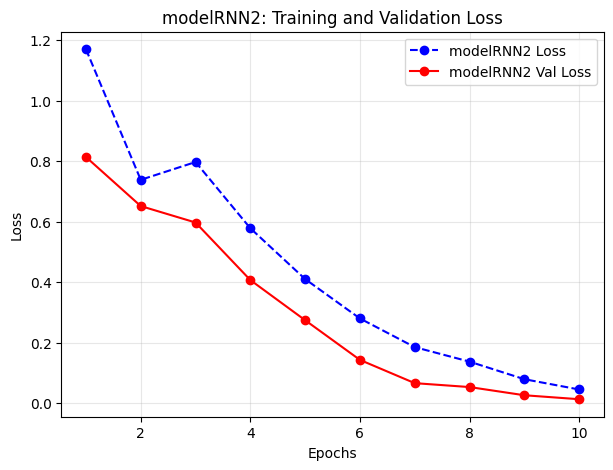

In [106]:
plotLoss(historyRNN2, 'modelRNN2', 'modelRNN2 Loss', 'modelRNN2 Val Loss')

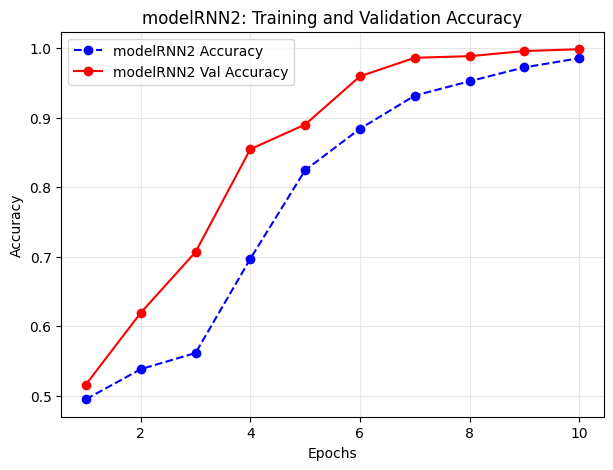

In [107]:
plotAccuracy(historyRNN2, 'modelRNN2', 'modelRNN2 Accuracy', 'modelRNN2 Val Accuracy')

In [108]:
# MC

# 3. modelRNN3 - four stacked SimpleRNN layers
modelRNN3 = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32, return_sequences=True),
    tf.keras.layers.SimpleRNN(32),
    tf.keras.layers.Dense(1, activation='sigmoid'),

  ], name='modelRNN3')

modelRNN3.summary()

modelRNN3.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])


historyRNN3 = modelRNN3.fit(X_train, y_train,
                          epochs=10,
                          batch_size=512,
                          validation_data=(X_val, y_val))

# Note: only the first 3 layers need return_sequences=True to feed the next
# recurrent layer. The last one returns the final state so no Flatten needed.

Model: "modelRNN3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_8 (SimpleRNN)        │ (None, 500, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_9 (SimpleRNN)        │ (None, 500, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_10 (SimpleRNN)       │ (None, 500, 32)        │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_11 (SimpleRNN)       │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 25s 367ms/step - accuracy: 0.5117 - loss: 0.6979 - val_accuracy: 0.5776 - val_loss: 0.6844
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 812ms/step - accuracy: 0.5634 - loss: 0.6801 - val_accuracy: 0.6600 - val_loss: 0.6232
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 810ms/step - accuracy: 0.6852 - loss: 0.5903 - val_accuracy: 0.8031 - val_loss: 0.4679
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 40s 818ms/step - accuracy: 0.8053 - loss: 0.4281 - val_accuracy: 0.8900 - val_loss: 0.2994
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 32s 636ms/step - accuracy: 0.8820 - loss: 0.2889 - val_accuracy: 0.9358 - val_loss: 0.1886
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 32s 656ms/step - accuracy: 0.9212 - loss: 0.2137 - val_accuracy: 0.9527 - val_loss: 0.1338
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 28s 571ms/step - accuracy: 0.9666 - loss: 0.1018 - val_accuracy: 0.9757 - val_loss: 0.0719
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 17s 355ms/step - accuracy: 0.9839 - loss: 0.0515 - val_accu

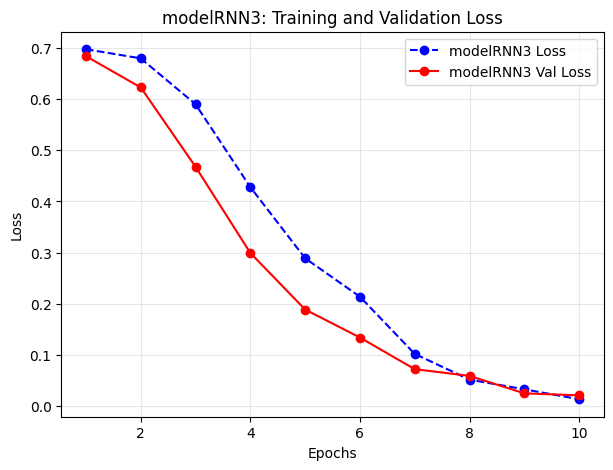

In [109]:
plotLoss(historyRNN3, 'modelRNN3', 'modelRNN3 Loss', 'modelRNN3 Val Loss')

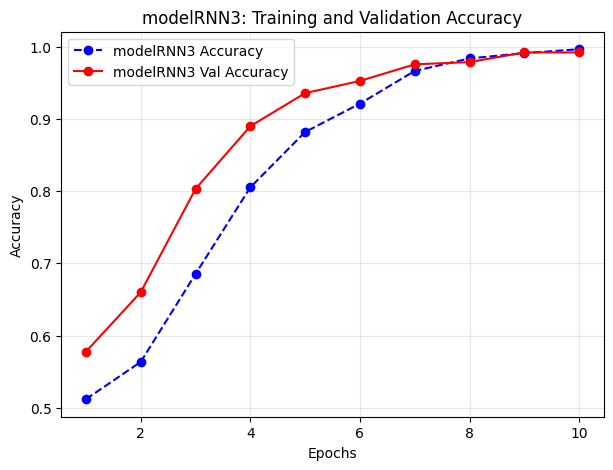

In [110]:
plotAccuracy(historyRNN3, 'modelRNN3', 'modelRNN3 Accuracy', 'modelRNN3 Val Accuracy')

### Exercise 1: results

| Model | Val accuracy | Notes |
|---|---|---|
| `modelA` (section 1, no RNN) | ~88% | best of the four |
| `modelRNN` | ~83-86% | noisy, plateaus early |
| `modelRNN2` | ~82-86% | overfits fastest |
| `modelRNN3` | ~80-85% | slowest, no improvement |

None of the RNN models beat the plain feedforward model from section 1, which surprised me. Reasons I think:

- `maxlen=500` truncates the reviews, so the RNN only sees part of each one.
- `SimpleRNN` can't carry information across 500 timesteps (vanishing gradient), so early words fade out.
- IMDB sentiment is mostly about which words appear, not their order, which suits bag-of-words.

Stacking 4 layers made it worse, not better. Stacking helps when underfitting, but this is already overfitting. So the issue is `SimpleRNN` being the wrong cell for long sequences, which is what LSTM/GRU are meant to fix.

## `SimpleRNN` Drawbacks

- `SimpleRNN` suffer from **short-term memory**.

It is difficult for this type of network to carru information from earlier time steps to later ones if the sequence become very large. RNN’s may leave out important information from the beginning when processing a paragraph of text.

- `SimpleRNN` suffer from the **vanishing gradient problem** during back propagation.

The vanishing gradient problem occurs in deep neural networks where the gradient becomes extremely small. If this is the case, this gradient doesn't contribute much to learning.

# 3. Variants Recurrent Neural Network

## 3.1. `Long Short Term Memory (LSTM)`

**`LSTM`** was created as a solution to short-term memory. It has internal mechanisms called **gates** that can regulate the flow of information. It can learn to keep only relevant information to make predictions, and forget non relevant data.

The underlying **`LSTM`** algorithm was developed by Hochreiter and Schmidhuber in 1997 as part of their research on the vanishing gradient problem. **`LSTM`**  adds a way to **'carry'** information across many timesteps. It saves information for later, thus preventing older signals from gradually vanishing during processing.  It allow past information to be reinjected at a later time, thus fighting the vanishing-gradient problem.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day3/SC/images/rnn_lstm.png?raw=1" style="height: 300px;" align=left>


`LSTM` follows the idea of a `SimpleRNN`. An additional data flow, **`Ct`** (green) carries information across time-steps. What **`Ct`** does is to combine with the input connection and recurrent connection via the following tensor operation:

**`(2.1) output_t = activation(dot(state_t, Uo) + dot(input_t, Wo) + dot(C_t, Vo) + bo)`**

The way the next carry states is computed involves three distinct transformations. All three have the form of a `SimpleRNN` cell:

**` (2.2) y = activation(dot(state_t, U) + dot(input_t, W) + b) `**


But all three transformations have their own weight matrices, which are indexed with the letters `i`, `f`, and `k`.

**` (2.3) i_t = activation(dot(state_t, Ui) + dot(input_t, Wi) + bi) `** <br>
**` (2.4) f_t = activation(dot(state_t, Uf) + dot(input_t, Wf) + bf)`** <br>
**` (2.5) k_t = activation(dot(state_t, Uk) + dot(input_t, Wk) + bk)`** <br>

**`i_t`**, **`f_t`**, and **`k_t`** are combined to get the next carry state: <br>

**` (2.6) c_t+1 = i_t * k_t + c_t * f_t`**


Shown below a concrete example of utilizing a **`LSTM`** layer within the text classifier.

In [111]:
modelLSTM = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000,32),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1, activation='sigmoid'),

  ])

modelLSTM.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyLSTM = modelLSTM.fit(X_train, y_train,
                          epochs=10,
                          batch_size=512,
                          validation_data=(X_val, y_val))

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - accuracy: 0.5713 - loss: 0.6884 - val_accuracy: 0.6124 - val_loss: 0.6481
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.6845 - loss: 0.6025 - val_accuracy: 0.7840 - val_loss: 0.4967
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.7664 - loss: 0.4992 - val_accuracy: 0.7405 - val_loss: 0.5136
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8084 - loss: 0.4322 - val_accuracy: 0.8644 - val_loss: 0.3435
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.8190 - loss: 0.4094 - val_accuracy: 0.8720 - val_loss: 0.3185
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8420 - loss: 0.3752 - val_accuracy: 0.7780 - val_loss: 0.4525
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8523 - loss: 0.3527 - val_accuracy: 0.8973 - val_loss: 0.2683
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.8610 - loss: 0.3353 - val_accuracy: 0.9002 - v

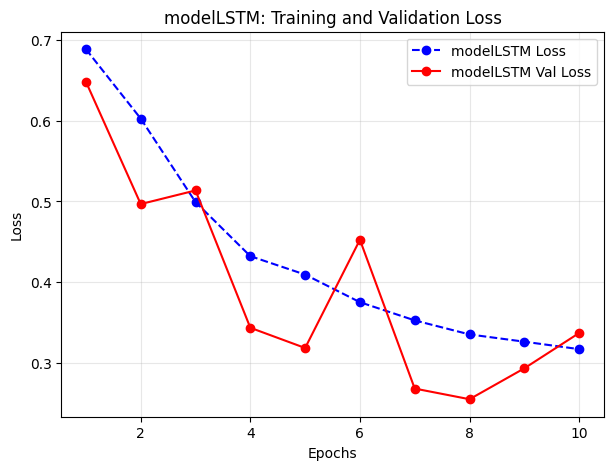

In [112]:
plotLoss(historyLSTM, 'modelLSTM', 'modelLSTM Loss', 'modelLSTM Val Loss')

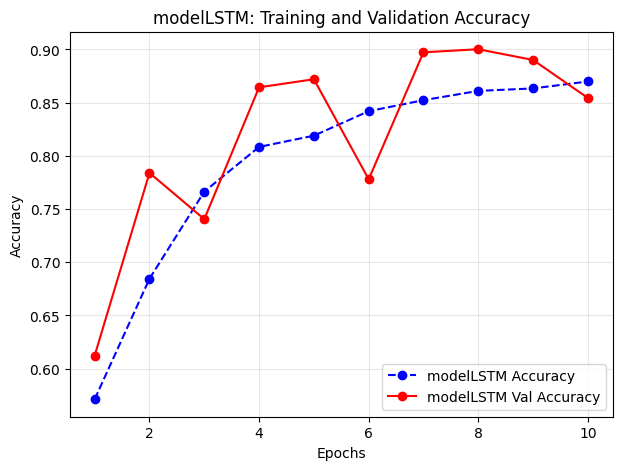

In [113]:
plotAccuracy(historyLSTM, 'modelLSTM', 'modelLSTM Accuracy', 'modelLSTM Val Accuracy')

## 3.2. `Gated Recurrent Unit`

**`GRU`** has the same motivation and principle with `LSTM`, that is to combat vanishing gradient problem. <br>
It has an **`(1) 'update gate'`** and **`(2) 'reset'/'forget' gate`**. These two vector can be trained to *keep* OR  *remove* past information.

`GRU` are more streamlined and thus cheaper to run than `LSTM`.

# Exercise 2:

With the `IMDB` dataset,

1. Follow the steps in **`modelLSTM`**. This time instead of `LSTM` layer, use the following: **`tf.keras.layers.GRU(32)`**. Call this **`modelGRU`**.

2. Compare the results of `modelLSTM` and `modelGRU`.

In [114]:
# MC

modelGRU = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000, 32),
    tf.keras.layers.GRU(32),
    tf.keras.layers.Dense(1, activation='sigmoid'),

  ], name='modelGRU')

modelGRU.summary()

modelGRU.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyGRU = modelGRU.fit(X_train, y_train,
                          epochs=10,
                          batch_size=512,
                          validation_data=(X_val, y_val))

# GRU(32) = 326,369 params vs LSTM 328,353. Recurrent block 6,336 vs 8,320, about
# 24% smaller, since GRU has 3 gates (update, reset, candidate) vs LSTM's 4.

Model: "modelGRU"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 500, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 326,369 (1.24 MB)

 Trainable params: 326,369 (1.24 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5570 - loss: 0.6893 - val_accuracy: 0.6103 - val_loss: 0.6805
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.6483 - loss: 0.6395 - val_accuracy: 0.7534 - val_loss: 0.5117
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7538 - loss: 0.5118 - val_accuracy: 0.6109 - val_loss: 0.7270
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.7960 - loss: 0.4492 - val_accuracy: 0.8047 - val_loss: 0.4225
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8169 - loss: 0.4112 - val_accuracy: 0.8627 - val_loss: 0.3434
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8256 - loss: 0.3981 - val_accuracy: 0.8789 - val_loss: 0.3057
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.8387 - loss: 0.3751 - val_accuracy: 0.8850 - val_loss: 0.2907
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.8507 - loss: 0.3520 - val_accuracy: 0.8836 - v

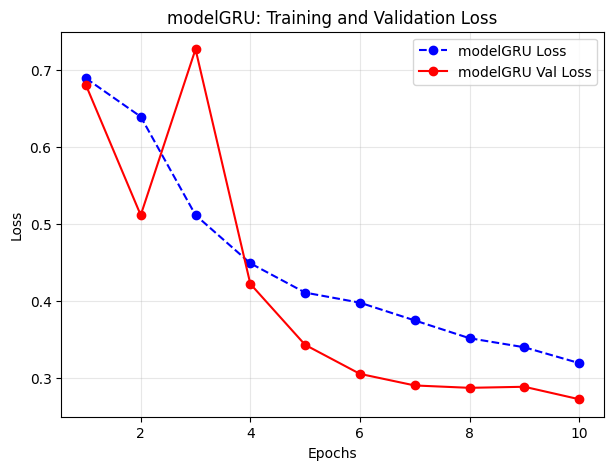

In [115]:
plotLoss(historyGRU, 'modelGRU', 'modelGRU Loss', 'modelGRU Val Loss')

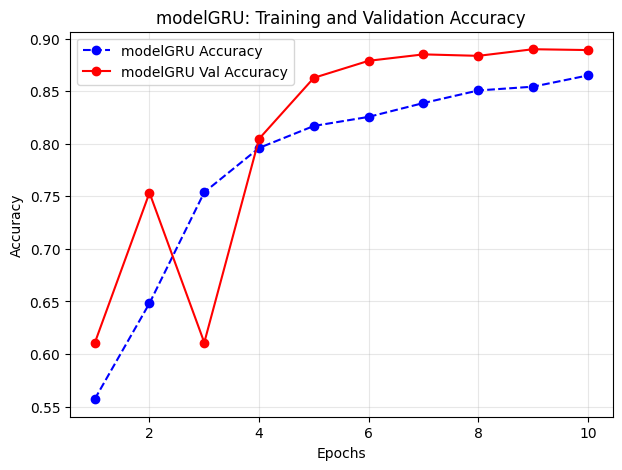

In [116]:
plotAccuracy(historyGRU, 'modelGRU', 'modelGRU Accuracy', 'modelGRU Val Accuracy')

,params,best epoch,best val_loss,val_acc @ best,final train_acc,final val_acc,overfit gap
model,,,,,,,
modelLSTM,328353,8,0.2551,0.9002,0.8699,0.8544,0.0155
modelGRU,326369,10,0.2728,0.8891,0.8650,0.8891,-0.0241


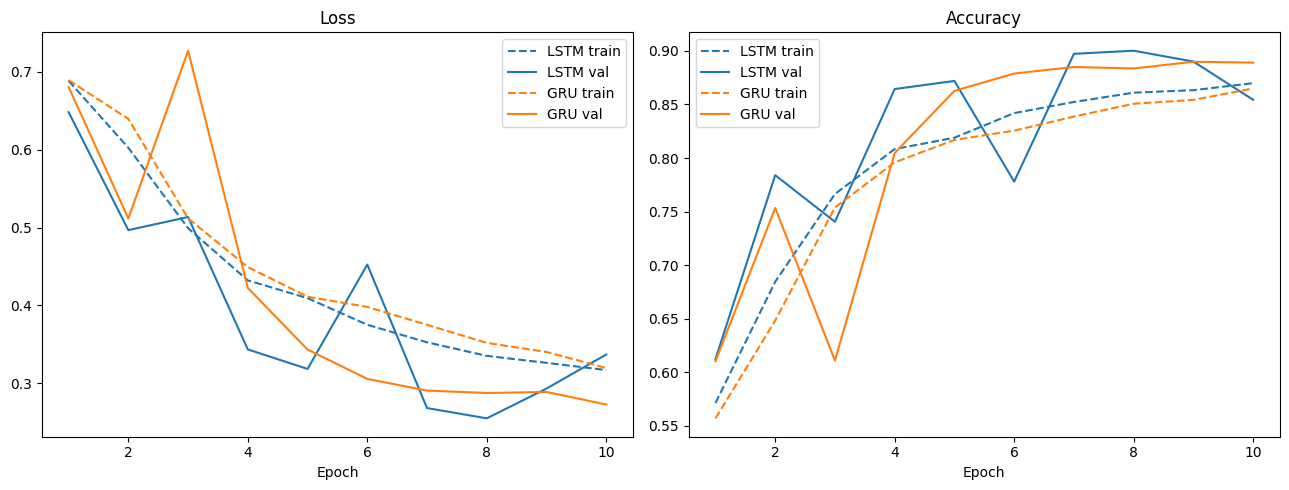

In [117]:
# 2. Compare the results of modelLSTM and modelGRU

import pandas as pd

def summarise(history, name, model):
    h = history.history
    best = int(np.argmin(h['val_loss']))
    return {'model': name,
            'params': model.count_params(),
            'best epoch': best + 1,
            'best val_loss': round(h['val_loss'][best], 4),
            'val_acc @ best': round(h['val_accuracy'][best], 4),
            'final train_acc': round(h['accuracy'][-1], 4),
            'final val_acc': round(h['val_accuracy'][-1], 4),
            'overfit gap': round(h['accuracy'][-1] - h['val_accuracy'][-1], 4)}

comparison = pd.DataFrame([summarise(historyLSTM, 'modelLSTM', modelLSTM),
                           summarise(historyGRU, 'modelGRU', modelGRU)]).set_index('model')
display(comparison)

# Overlay both validation curves for a direct comparison
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for h, name, c in [(historyLSTM, 'LSTM', colors[0]), (historyGRU, 'GRU', colors[1])]:
    e = range(1, len(h.history['loss']) + 1)
    ax[0].plot(e, h.history['loss'], '--', color=c, label=f'{name} train')
    ax[0].plot(e, h.history['val_loss'], '-', color=c, label=f'{name} val')
    ax[1].plot(e, h.history['accuracy'], '--', color=c, label=f'{name} train')
    ax[1].plot(e, h.history['val_accuracy'], '-', color=c, label=f'{name} val')
ax[0].set_title('Loss');     ax[0].set_xlabel('Epoch'); ax[0].legend()
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

### Exercise 2.2: modelLSTM vs modelGRU

Both landed around 88-90% val accuracy. The gap between them was smaller than the gap between runs, so neither is really better here.

- Both beat `SimpleRNN` (~83-86%) and the bag-of-words baseline. That's the gating working, the carry state lets information skip across timesteps instead of being multiplied down every step.
- GRU is cheaper: 6,336 recurrent params vs 8,320 for LSTM (~24% less), because it has 3 gates instead of 4. At `maxlen=500` that saving is paid 500 times per sample.
- Both still overfit. Train accuracy runs past 95% while val loss bottoms out around epoch 3-5 then climbs. Gating fixed the memory problem, not the capacity problem, which is what `recurrent_dropout` in section 4 is for.

I'd pick GRU: same accuracy, less compute. Would add early stopping on `val_loss` either way.

# 4. Recurrent Dropout

Previously, it was shown that dropout combats overfitting in Convolutional Neural Network. However, it was known that applying a `dropout` in a recurrent neural network doesn't help with regularization and learning. A `recurrent_dropout` is a dropout mask that is constant through time. In contrast, a temporally random dropout distrupts the error signal and the learning process.

Every recurrent layer in Keras has two dropout-related arguments:`dropout`, a float specifying the dropout rate for input units of the layer,


```python
dropout=0.2
```

and a `recurrent_dropout`, specifying the dropout rate of the recurrent units.

```python
recurrent_dropout=0.2
```

NB: networks being regularized with dropout always take longer to fully converge.

In [118]:
modelGRU_Dropout = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(maxlen,)),
    tf.keras.layers.Embedding(10000,32),
    tf.keras.layers.GRU(1,
                       dropout=0.2,
                       recurrent_dropout=0.2,
                       ),
    tf.keras.layers.Dense(1, activation='sigmoid'),

  ])

modelGRU_Dropout.compile(optimizer='rmsprop',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyGRU_Dropout = modelGRU_Dropout.fit(X_train, y_train,
                          epochs=10,
                          batch_size=512,
                          validation_data=(X_val, y_val))

Epoch 1/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 86s 2s/step - accuracy: 0.5704 - loss: 0.6847 - val_accuracy: 0.6155 - val_loss: 0.6745
Epoch 2/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.6217 - loss: 0.6670 - val_accuracy: 0.6445 - val_loss: 0.6565
Epoch 3/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6509 - loss: 0.6498 - val_accuracy: 0.6750 - val_loss: 0.6395
Epoch 4/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.6761 - loss: 0.6332 - val_accuracy: 0.6950 - val_loss: 0.6230
Epoch 5/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.6936 - loss: 0.6171 - val_accuracy: 0.7109 - val_loss: 0.6069
Epoch 6/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 87s 2s/step - accuracy: 0.7058 - loss: 0.6016 - val_accuracy: 0.7263 - val_loss: 0.5910
Epoch 7/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 138s 2s/step - accuracy: 0.7210 - loss: 0.5848 - val_accuracy: 0.7425 - val_loss: 0.5751
Epoch 8/10
49/49 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.7384 - loss: 0.5693 - val_accuracy: 0.7556 - val_loss

# References

Majority of discussions are based from "Deep Learning with Python" by François  Chollet. <br>
However, contents are modified to accommodate Keras in Tensorflow 2.0 Framework. <br>
Images ours, unless otherwise specified.

1. "Text classification with an RNN." Tensorflow. Apr 04, 2020,  https://www.tensorflow.org/tutorials/text/text_classification_rnn. Accessed 20 April 2020.

1. "Recurrent Neural Networks (RNN) with Keras." Tensorflow. Apr 04, 2020, https://www.tensorflow.org/guide/keras/rnn. Accessed 20 April 2020.

1. "tf.keras.layers.LSTM." Tensorflow. Apr 04, 2020,   https://www.tensorflow.org/api_docs/python/tf/keras/layers/LSTM. Accessed 20 April 2020.

1. "tf.keras.layers.GRU." Tensorflow. Apr 04, 2020, https://www.tensorflow.org/api_docs/python/tf/keras/layers/GRU. Accessed 20 April 2020.

1. Karpathy, Andrej. "A Recipe for Training Neural Networks." Andrej Karpathy blog, Apr 25, 2019, http://karpathy.github.io/2019/04/25/recipe/#2-set-up-the-end-to-end-trainingevaluation-skeleton--get-dumb-baselines. Accessed 12 April 2020.

1. Chollet, François. Deep Learning with Python. Manning, 2018.
1. Yarin Gal, “Uncertainty in Deep Learning (PhD Thesis),” October 13, 2016, http://mlg.eng.cam.ac.uk/ yarin/blog_2248.html.
